In [60]:
import numpy as np
import matplotlib.pyplot as plt

In [61]:
alpha = 0


In [62]:
# Telescope Field of View (FOV) in deg^2
telescope_fov = {
    'MeerKAT_CB': 0.4,  
    'MeerKAT_IB': 1.27,     
    'Parkes': 0.56,       
    'FAST': 0.061,          
    'ASKAP_flyeye': 160, 
    'ASKAP_ICS': 20,   
}

In [63]:
# path = 'DM_distribution_stdc'
path = 'DM_distribution'

In [64]:
DM_detected_meerkat_CB = np.load(f'{path}/dm_detected_meerkat_{alpha}_CB.npy')
DM_detected_meerkat_IB = np.load(f'{path}/dm_detected_meerkat_{alpha}_IB.npy')
# DM_detected_meerkat_all = np.load(f'{path}/dm_detected_meerkat_{alpha}_all.npy')
DM_detected_PKS_cen = np.load(f'{path}/dm_detected_PKS_{alpha}_cen.npy')
DM_detected_PKS_inn = np.load(f'{path}/dm_detected_PKS_{alpha}_inn.npy')
DM_detected_PKS_out = np.load(f'{path}/dm_detected_PKS_{alpha}_out.npy')    
DM_detected_FAST = np.load(f'{path}/dm_detected_fast_{alpha}.npy')
DM_detected_FAST = np.load(f'{path}/dm_detected_fast_{alpha}.npy')
# DM_detected_askap_flyeye_1dish1beam = np.load(f'{path}/dm_detected_askap_{alpha}_flyeye.npy')
DM_detected_askap_flyeye_1dish1beam = np.load('/home/thsu/FRB_population/ASKAP_flyeye_new/dm_detected_askap_combined_full.npy')
# DM_detected_askap_ics = np.load(f'{path}/dm_detected_ASKAP_{alpha}_ics.npy')
DM_detected_PKS_all = np.concatenate([DM_detected_PKS_inn] * 6 +[DM_detected_PKS_out] * 6 +[DM_detected_PKS_cen])
DM_detected_FAST_all = np.concatenate([DM_detected_FAST] * 19)
DM_detected_askap_flyeye_all = np.concatenate([DM_detected_askap_flyeye_1dish1beam] )

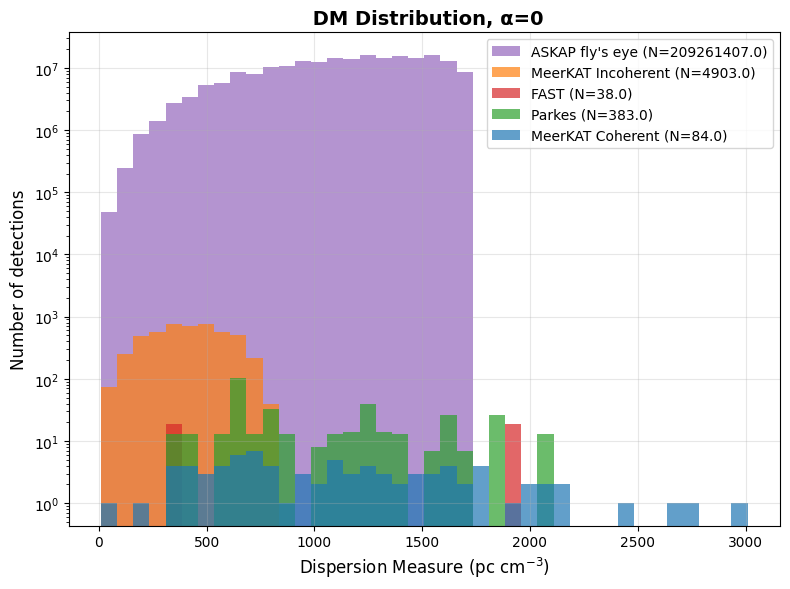

In [65]:
plt.figure(figsize=(8, 6), dpi=100)

# Define common bins for all three histograms
dm_min = min(DM_detected_meerkat_CB.min(), DM_detected_meerkat_IB.min(), DM_detected_PKS_all.min(), DM_detected_FAST_all.min())
dm_max = max(DM_detected_meerkat_CB.max(), DM_detected_meerkat_IB.max(), DM_detected_PKS_all.max(), DM_detected_FAST_all.max())
common_bins = np.linspace(dm_min, dm_max, 41)  # 40 bins

# --- Create weights for normalization ---
# weights_meerkat_CB = np.full_like(DM_detected_meerkat_CB, telescope_fov['MeerKAT_CB'])
# weights_meerkat_IB = np.full_like(DM_detected_meerkat_IB, telescope_fov['MeerKAT_IB'])
# weights_pks = np.full_like(DM_detected_PKS_all, telescope_fov['Parkes'])
# weights_fast = np.full_like(DM_detected_FAST_all, telescope_fov['FAST'])
# weights_askap_flyeye = np.full_like(DM_detected_askap_flyeye_all, telescope_fov['ASKAP_flyeye'])
# weights_askap_ics = np.full_like(DM_detected_askap_ics, telescope_fov['ASKAP_ICS'])
                                 
weights_meerkat_CB = np.full_like(DM_detected_meerkat_CB, 1)
weights_meerkat_IB = np.full_like(DM_detected_meerkat_IB, 1)
weights_pks = np.full_like(DM_detected_PKS_all, 1)
weights_fast = np.full_like(DM_detected_FAST_all, 1)
weights_askap_flyeye = np.full_like(DM_detected_askap_flyeye_all, 1)
# weights_askap_ics = np.full_like(DM_detected_askap_ics, 1)

# --- Calculate total normalized rates for the legend ---
rate_meerkat_CB = np.round(np.sum(weights_meerkat_CB))
rate_meerkat_IB = np.round(np.sum(weights_meerkat_IB))
rate_pks = np.round(np.sum(weights_pks))
rate_fast = np.round(np.sum(weights_fast))
rate_askap_flyeye = np.round(np.sum(weights_askap_flyeye))
# rate_askap_ics = np.round(np.sum(weights_askap_ics))

# --- Plot the histograms using the weights parameter ---

# plt.hist(DM_detected_askap_ics, bins=common_bins, weights=weights_askap_ics, color='black', alpha=0.7,
#          label=f'ASKAP ICS (N={rate_askap_ics:.1f})')

plt.hist(DM_detected_askap_flyeye_all, bins=common_bins, weights=weights_askap_flyeye, color='tab:purple', alpha=0.7,
         label=f'ASKAP fly\'s eye (N={rate_askap_flyeye:.1f})')

plt.hist(DM_detected_meerkat_IB, bins=common_bins, weights=weights_meerkat_IB, color='tab:orange', alpha=0.7,
         label=f'MeerKAT Incoherent (N={rate_meerkat_IB:.1f})')

plt.hist(DM_detected_FAST_all, bins=common_bins, weights=weights_fast, color='tab:red', alpha=0.7,
         label=f'FAST (N={rate_fast:.1f})')


plt.hist(DM_detected_PKS_all, bins=common_bins, weights=weights_pks, color='tab:green', alpha=0.7,
         label=f'Parkes (N={rate_pks:.1f})')



plt.hist(DM_detected_meerkat_CB, bins=common_bins, weights=weights_meerkat_CB, color='tab:blue', alpha=0.7,
         label=f'MeerKAT Coherent (N={rate_meerkat_CB:.1f})')




plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)


plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)
plt.ylabel('Number of detections', fontsize=12)
plt.title(f' DM Distribution, α={alpha}', fontsize=14, fontweight='bold')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [66]:
ff = np.load('/home/thsu/FRB_population/ASKAP_flyeye_new/dm_detected_askap_combined_full.npy')
print(ff)

[  10.   10.   10. ... 1700. 1700. 1700.]
